## **Section 1: NHS GP Appointment System Analysis**
General Practice (GP) services form the foundation of primary healthcare delivery in England. GP practices manage a substantial proportion of patient interactions within the healthcare system, providing consultations, referrals, and ongoing management of health conditions. As a result, millions of GP appointments are delivered every month across the country.

Understanding patterns in appointment demand and service delivery is important for effective healthcare planning and resource allocation. Analysing appointment volumes, consultation modes, and temporal trends can provide insights into how primary care services are utilised and how capacity is distributed across the system.

The data used in this section comes from the Appointments in General Practice statistical publication produced by NHS England. This dataset provides aggregated information on GP appointment activity in England, including appointment counts, consultation modes, and workforce utilisation.

In [ ]:
import sys
!{sys.executable} -m pip install openpyxl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Load the Dataset
df = pd.read_excel('/content/drive/MyDrive/GP No show Project/GP_DNA_Monthly_Dataset Uncleaned.xlsx',
                   sheet_name='GP_DNA_Dataset',
                   header=2)

In [ ]:
print(df.shape)
print(df.columns.tolist())
print(df.head(3))
print(df.dtypes)
print(df.isnull().sum())

(30, 67)
['Month', 'Total Appts', 'Working Days', 'Registered Patients', 'Attended', 'DNA Count', 'Unknown Status', '% Attended', '% DNA', '% Unknown', 'Face-to-Face', 'Telephone', 'Video/Online', 'Home Visit', '% F2F', '% Tel', '% Video', 'Same Day', '1 Day', '2–7 Days', '8–14 Days', '15–21 Days', '22–28 Days', '>28 Days', '% Same Day', '% 1 Day', '% 2–7d', '% 8–14d', '% 15–21d', '% 22–28d', '% >28d', 'Acute Consult', 'Routine Consult', 'Clinical Triage', 'Planned Clinics', 'Unplanned Activity', 'GP Appts', 'Nurse Appts', 'Other DPC Appts', '% GP', '% Nurses', '% Other DPC', 'PCN Total Appts', 'PCN Attended', 'PCN DNA Count', 'PCN Unknown', '% Attended.1', '% DNA.1', '% Unknown.1', 'F2F', 'Telephone.1', 'Video/Online.1', 'Home Visit.1', 'Same Day.1', '1 Day.1', '2–7 Days.1', '8–14 Days.1', '15–21 Days.1', '22–28 Days.1', '>28 Days.1', '% Same Day.1', '% >28d.1', 'Extended Access', 'Social Prescribing', 'GP Appts.1', 'PCN Appts', 'Total (GP+PCN)']
     Month  Total Appts  Working Days 

In [ ]:
# Cleaning the data
gp_data= pd.DataFrame()

gp_data['Month']= df['Month']
gp_data['Total_Appointments'] = df['Total Appts'] + df['PCN Total Appts']
gp_data['Working_Days']         = df['Working Days']
gp_data['Registered_Patients']  = df['Registered Patients']

In [ ]:
#Combined Attendance Column (GP+PCN)
gp_data['Total_Attended']= df['Attended']+df['PCN Attended']
gp_data['Total_DNA']            = df['DNA Count']      + df['PCN DNA Count']
gp_data['Total_Unknown_Status'] = df['Unknown Status'] + df['PCN Unknown']

In [ ]:
#Percentage of the combined columns
gp_data['Pct_Attended'] = gp_data['Total_Attended']       / gp_data['Total_Appointments']
gp_data['Pct_DNA']      = gp_data['Total_DNA']            / gp_data['Total_Appointments']
gp_data['Pct_Unknown']  = gp_data['Total_Unknown_Status'] / gp_data['Total_Appointments']

In [ ]:
# Combined Mode Columns (GP+PCN)
gp_data['Total_F2F']= df['Face-to-Face'] + df['F2F']
gp_data['Total_Tel']= df['Telephone'] + df['Telephone.1']
gp_data ['Total_Video_Online'] = df['Video/Online'] + df['Video/Online.1']
gp_data['Total_Home_Visit']   = df['Home Visit']   + df['Home Visit.1']

In [ ]:
# Combined Waiting Time Columns
gp_data['Total_SameDay']    = df['Same Day']   + df['Same Day.1']
gp_data['Total_1Day']       = df['1 Day']      + df['1 Day.1']
gp_data['Total_2to7Days']   = df['2–7 Days']   + df['2–7 Days.1']
gp_data['Total_8to14Days']  = df['8–14 Days']  + df['8–14 Days.1']
gp_data['Total_15to21Days'] = df['15–21 Days'] + df['15–21 Days.1']
gp_data['Total_22to28Days'] = df['22–28 Days'] + df['22–28 Days.1']
gp_data['Total_Over28Days'] = df['>28 Days']   + df['>28 Days.1']


In [ ]:
print(gp_data.head(5))

     Month  Total_Appointments  Working_Days  Registered_Patients  \
0  2023-07            28598376            21             62553815   
1  2023-08            29029353            22             62637854   
2  2023-09            31987808            21             62690784   
3  2023-10            35128197            22             62797874   
4  2023-11            32384750            22             62945224   

   Total_Attended  Total_DNA  Total_Unknown_Status  Pct_Attended   Pct_DNA  \
0        25766044    1297099               1535233      0.900962  0.045356   
1        26162600    1297474               1569279      0.901246  0.044695   
2        28254262    1666838               2066708      0.883282  0.052109   
3        30896760    1851222               2380215      0.879543  0.052699   
4        28940074    1531776               1912900      0.893633  0.047299   

   Pct_Unknown  ...  Total_Tel  Total_Video_Online  Total_Home_Visit  \
0     0.053683  ...    7594995              

In [ ]:
#Formatting Month column to DateTime
gp_data['Month'] = pd.to_datetime(gp_data['Month'], format= '%Y-%m')
print(gp_data['Month'].dtype)
print(gp_data['Month'].head())

datetime64[ns]
0   2023-07-01
1   2023-08-01
2   2023-09-01
3   2023-10-01
4   2023-11-01
Name: Month, dtype: datetime64[ns]


In [ ]:
#Resetting the Index
gp_data= gp_data.sort_values('Month').reset_index(drop=True)

In [ ]:
print(gp_data.shape)
print(gp_data.isnull().sum())
print(gp_data.dtypes)
print(gp_data.head())
print(gp_data.tail())

(30, 21)
Month                   0
Total_Appointments      0
Working_Days            0
Registered_Patients     0
Total_Attended          0
Total_DNA               0
Total_Unknown_Status    0
Pct_Attended            0
Pct_DNA                 0
Pct_Unknown             0
Total_F2F               0
Total_Tel               0
Total_Video_Online      0
Total_Home_Visit        0
Total_SameDay           0
Total_1Day              0
Total_2to7Days          0
Total_8to14Days         0
Total_15to21Days        0
Total_22to28Days        0
Total_Over28Days        0
dtype: int64
Month                   datetime64[ns]
Total_Appointments               int64
Working_Days                     int64
Registered_Patients              int64
Total_Attended                   int64
Total_DNA                        int64
Total_Unknown_Status             int64
Pct_Attended                   float64
Pct_DNA                        float64
Pct_Unknown                    float64
Total_F2F                        int64
Tot

In [ ]:
#Rechecking
check = gp_data['Total_Attended'] + gp_data['Total_DNA'] + gp_data['Total_Unknown_Status']
diff  = check - gp_data['Total_Appointments']

print(diff)
print((diff == 0).all())

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
28    0
29    0
dtype: int64
True


# **Section 1: NHS Service Context**

This section analyses GP appointment data published by NHS England, covering
July 2023 to December 2025. The dataset combines activity recorded in both GP
practice appointment systems (Table 1a) and Primary Care Network (PCN)
appointment systems (Table 1b), providing a comprehensive view of primary care
activity across England.

The analysis is structured into four blocks:
- **Block 1:** GP Appointment Demand
- **Block 2:** Consultation Mode Analysis
- **Block 3:** Waiting Time Distribution
- **Block 4:** DNA Overview


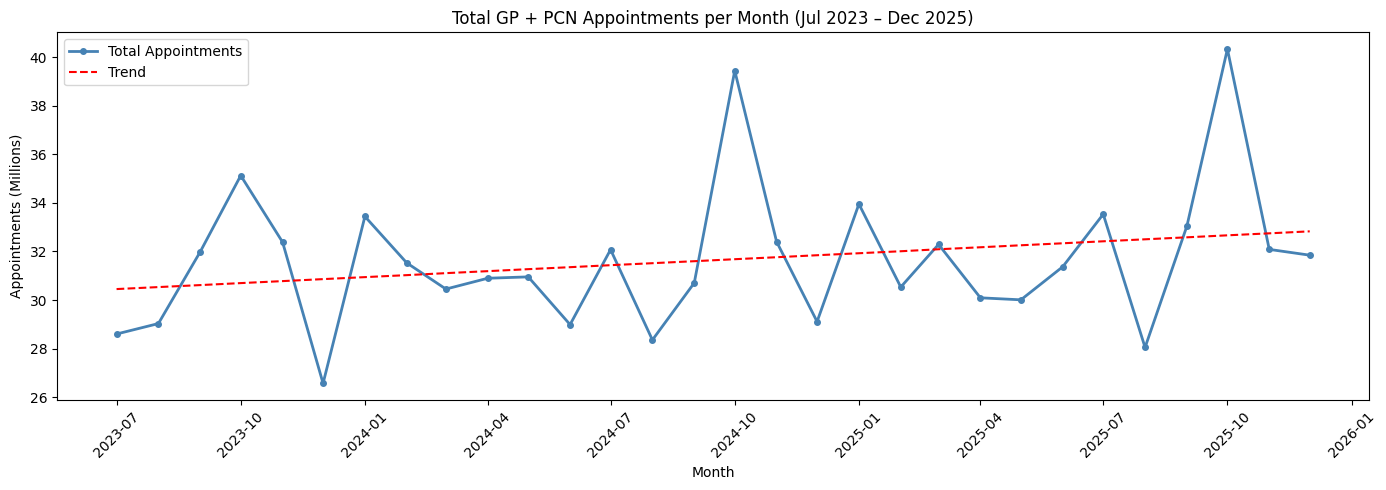

In [ ]:
#Block 1: Demand Analysis
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

#total appointment over time
plt.figure(figsize=(14, 5))

plt.plot(gp_data['Month'], gp_data['Total_Appointments'] / 1000000,
         color='steelblue', linewidth=2, marker='o', markersize=4,
         label='Total Appointments')

# add a trend line
z = np.polyfit(range(len(gp_data)), gp_data['Total_Appointments'] / 1000000, 1)
p = np.poly1d(z)
plt.plot(gp_data['Month'], p(range(len(gp_data))),
         linestyle='--', color='red', linewidth=1.5, label='Trend')

plt.title('Total GP + PCN Appointments per Month (Jul 2023 – Dec 2025)')
plt.xlabel('Month')
plt.ylabel('Appointments (Millions)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('demand_total.png', dpi=150)
plt.show()

In [ ]:
# analysis of total appointments

first_month = gp_data['Month'].iloc[0].strftime('%b %Y')
last_month  = gp_data['Month'].iloc[-1].strftime('%b %Y')
first_val   = gp_data['Total_Appointments'].iloc[0]
last_val    = gp_data['Total_Appointments'].iloc[-1]
growth      = (last_val - first_val) / first_val * 100

peak_val   = gp_data['Total_Appointments'].max()
peak_month = gp_data.loc[gp_data['Total_Appointments'].idxmax(), 'Month'].strftime('%b %Y')
low_val    = gp_data['Total_Appointments'].min()
low_month  = gp_data.loc[gp_data['Total_Appointments'].idxmin(), 'Month'].strftime('%b %Y')

# year on year average
gp_data['Year'] = gp_data['Month'].dt.year
yearly_avg = gp_data.groupby('Year')['Total_Appointments'].mean()

# month on month change
gp_data['MoM_Change'] = gp_data['Total_Appointments'].pct_change() * 100
biggest_jump = gp_data.loc[gp_data['MoM_Change'].idxmax()]
biggest_drop = gp_data.loc[gp_data['MoM_Change'].idxmin()]

print("ANALYSIS - TOTAL APPOINTMENTS")
print("-" * 40)
print(f"First month ({first_month}):  {first_val:,}")
print(f"Last month  ({last_month}):  {last_val:,}")
print(f"Overall change:              {round(growth, 1)}%")
print("")
print(f"Peak month:  {peak_month} ({peak_val:,})")
print(f"Lowest month: {low_month} ({low_val:,})")
print(f"Difference between peak and low: {peak_val - low_val:,}")
print("")
print("Average appointments by year:")
print(yearly_avg)
print("")
print(f"Biggest monthly jump: {biggest_jump['Month'].strftime('%b %Y')} ({round(biggest_jump['MoM_Change'], 1)}%)")
print(f"Biggest monthly drop: {biggest_drop['Month'].strftime('%b %Y')} ({round(biggest_drop['MoM_Change'], 1)}%)")

ANALYSIS - TOTAL APPOINTMENTS
----------------------------------------
First month (Jul 2023):  28,598,376
Last month  (Dec 2025):  31,846,937
Overall change:              11.4%

Peak month:  Oct 2025 (40,340,888)
Lowest month: Dec 2023 (26,565,214)
Difference between peak and low: 13,775,674

Average appointments by year:
Year
2023    3.061562e+07
2024    3.152951e+07
2025    3.226247e+07
Name: Total_Appointments, dtype: float64

Biggest monthly jump: Oct 2024 (28.5%)
Biggest monthly drop: Nov 2025 (-20.5%)


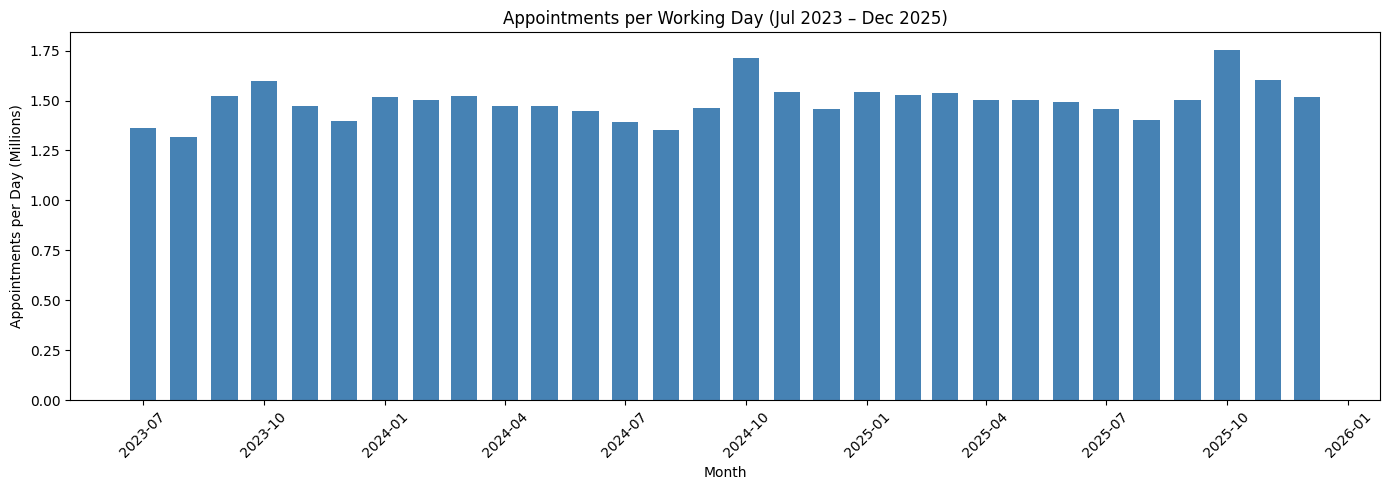

In [ ]:
# appointments per working day
gp_data['Appts_Per_WorkingDay'] = gp_data['Total_Appointments'] / gp_data['Working_Days']

plt.figure(figsize=(14, 5))

plt.bar(gp_data['Month'], gp_data['Appts_Per_WorkingDay'] / 1000000,
        color='steelblue', width=20)

plt.title('Appointments per Working Day (Jul 2023 – Dec 2025)')
plt.xlabel('Month')
plt.ylabel('Appointments per Day (Millions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('demand_per_workingday.png', dpi=150)
plt.show()

In [ ]:
# analysis of appointmnets per working day
avg_daily = gp_data['Appts_Per_WorkingDay'].mean()
peak_daily= gp_data['Appts_Per_WorkingDay'].max()
peak_month = gp_data.loc[gp_data['Appts_Per_WorkingDay'].idxmax(), 'Month'].strftime('%b %Y')
low_daily  = gp_data['Appts_Per_WorkingDay'].min()
low_month  = gp_data.loc[gp_data['Appts_Per_WorkingDay'].idxmin(), 'Month'].strftime('%b %Y')

# compare raw total vs working day adjusted for August and October
aug = gp_data[gp_data['Month'].dt.month == 8]['Appts_Per_WorkingDay'].mean()
oct = gp_data[gp_data['Month'].dt.month == 10]['Appts_Per_WorkingDay'].mean()
dec = gp_data[gp_data['Month'].dt.month == 12]['Appts_Per_WorkingDay'].mean()

print("ANALYSIS - APPOINTMENTS PER WORKING DAY")
print("-" * 40)
print(f"Average daily rate (all months): {round(avg_daily):,}")
print(f"Peak daily rate:  {peak_month} ({round(peak_daily):,})")
print(f"Lowest daily rate: {low_month} ({round(low_daily):,})")
print("")
print("Average daily rate by season:")
print(f"  August average:   {round(aug):,}")
print(f"  October average:  {round(oct):,}")
print(f"  December average: {round(dec):,}")
print("")
print(f"October is {round((oct - aug) / aug * 100, 1)}% busier per day than August")


ANALYSIS - APPOINTMENTS PER WORKING DAY
----------------------------------------
Average daily rate (all months): 1,495,812
Peak daily rate:  Oct 2025 (1,753,952)
Lowest daily rate: Aug 2023 (1,319,516)

Average daily rate by season:
  August average:   1,357,333
  October average:  1,688,621
  December average: 1,456,710

October is 24.4% busier per day than August


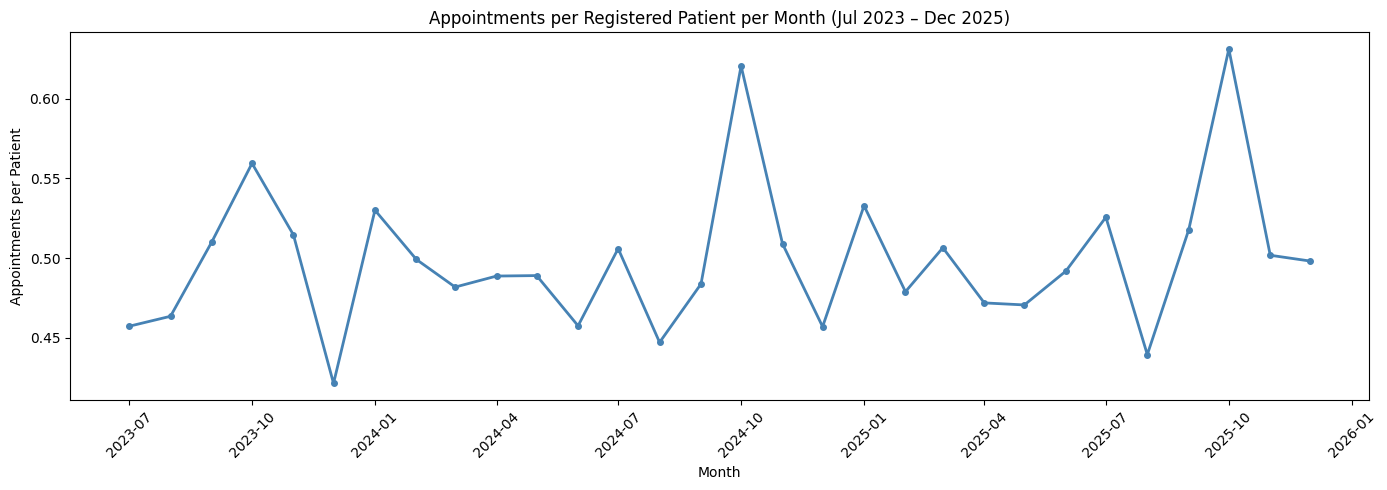

In [ ]:
#appopintments per registered patient
gp_data['Appts_Per_Patient'] = gp_data['Total_Appointments'] / gp_data['Registered_Patients']

plt.figure(figsize=(14, 5))

plt.plot(gp_data['Month'], gp_data['Appts_Per_Patient'],
         color='steelblue', linewidth=2, marker='o', markersize=4)

plt.title('Appointments per Registered Patient per Month (Jul 2023 – Dec 2025)')
plt.xlabel('Month')
plt.ylabel('Appointments per Patient')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('demand_per_patient.png', dpi=150)
plt.show()

In [ ]:
# registered patient growth
patient_growth = (gp_data['Registered_Patients'].iloc[-1] - gp_data['Registered_Patients'].iloc[0]) / gp_data['Registered_Patients'].iloc[0] * 100
print(f"Registered patients (Jul 2023): {gp_data['Registered_Patients'].iloc[0]:,}")
print(f"Registered patients (Dec 2025): {gp_data['Registered_Patients'].iloc[-1]:,}")
print(f"Patient list growth over period: {round(patient_growth, 1)}%")


Registered patients (Jul 2023): 62,553,815
Registered patients (Dec 2025): 63,939,909
Patient list growth over period: 2.2%


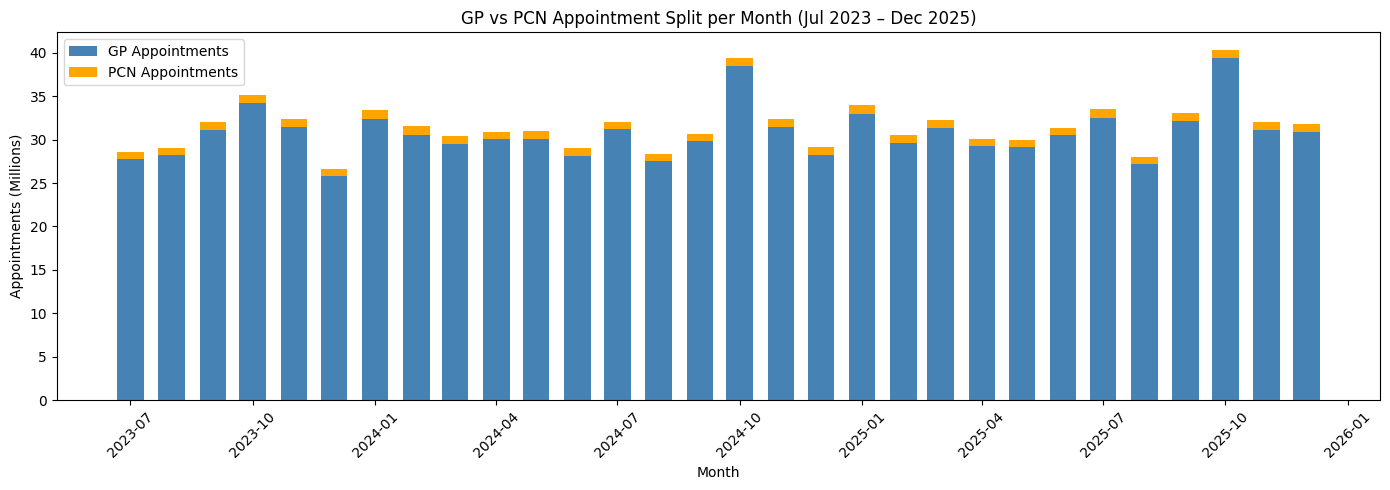

In [ ]:
# gp vs pcn split
# gp only appointments from original df
gp_only = df['Total Appts']
pcn_only = df['PCN Total Appts']

plt.figure(figsize=(14, 5))

plt.bar(gp_data['Month'], gp_only / 1000000,
        color='steelblue', width=20, label='GP Appointments')

plt.bar(gp_data['Month'], pcn_only / 1000000,
        bottom=gp_only / 1000000,
        color='orange', width=20, label='PCN Appointments')

plt.title('GP vs PCN Appointment Split per Month (Jul 2023 – Dec 2025)')
plt.xlabel('Month')
plt.ylabel('Appointments (Millions)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('gp_pcn_split.png', dpi=150)
plt.show()

In [ ]:
# analysis: GP vs PCN

gp_data['GP_Share']  = df['Total Appts']      / gp_data['Total_Appointments'] * 100
gp_data['PCN_Share'] = df['PCN Total Appts']  / gp_data['Total_Appointments'] * 100

avg_gp_share  = gp_data['GP_Share'].mean()
avg_pcn_share = gp_data['PCN_Share'].mean()

# has PCN share grown over time?
pcn_first = gp_data['PCN_Share'].iloc[0]
pcn_last  = gp_data['PCN_Share'].iloc[-1]
pcn_change = pcn_last - pcn_first

print("ANALYSIS - GP vs PCN SPLIT")
print("-" * 40)
print(f"Average GP share:  {round(avg_gp_share, 1)}%")
print(f"Average PCN share: {round(avg_pcn_share, 1)}%")
print("")
print(f"PCN share in Jul 2023: {round(pcn_first, 1)}%")
print(f"PCN share in Dec 2025: {round(pcn_last, 1)}%")
print(f"Change in PCN share:   {round(pcn_change, 1)} percentage points")
print("")
print(f"PCN appointments have {'grown' if pcn_change > 0 else 'shrunk'} as a share of total activity")

ANALYSIS - GP vs PCN SPLIT
----------------------------------------
Average GP share:  97.1%
Average PCN share: 2.9%

PCN share in Jul 2023: 2.9%
PCN share in Dec 2025: 3.1%
Change in PCN share:   0.1 percentage points

PCN appointments have grown as a share of total activity


In [ ]:
print("BLOCK 1 - DEMAND SUMMARY")
print("-" * 40)
print("Total appointments (30 months):", gp_data['Total_Appointments'].sum())
print("Average per month:", round(gp_data['Total_Appointments'].mean()))
print("Highest month:", gp_data.loc[gp_data['Total_Appointments'].idxmax(), 'Month'])
print("Highest value:", gp_data['Total_Appointments'].max())
print("Lowest month:", gp_data.loc[gp_data['Total_Appointments'].idxmin(), 'Month'])
print("Lowest value:", gp_data['Total_Appointments'].min())
print("Average appointments per working day:", round(gp_data['Appts_Per_WorkingDay'].mean()))
print("Average appointments per registered patient:", round(gp_data['Appts_Per_Patient'].mean(), 3))
print("Average GP share (%):", round((df['Total Appts'] / gp_data['Total_Appointments']).mean() * 100, 1))
print("Average PCN share (%):", round((df['PCN Total Appts'] / gp_data['Total_Appointments']).mean() * 100, 1))

BLOCK 1 - DEMAND SUMMARY
----------------------------------------
Total appointments (30 months): 949197489
Average per month: 31639916
Highest month: 2025-10-01 00:00:00
Highest value: 40340888
Lowest month: 2023-12-01 00:00:00
Lowest value: 26565214
Average appointments per working day: 1495812
Average appointments per registered patient: 0.499
Average GP share (%): 97.1
Average PCN share (%): 2.9


In [ ]:
print(gp_data.columns.tolist())

['Month', 'Total_Appointments', 'Working_Days', 'Registered_Patients', 'Total_Attended', 'Total_DNA', 'Total_Unknown_Status', 'Pct_Attended', 'Pct_DNA', 'Pct_Unknown', 'Total_F2F', 'Total_Tel', 'Total_Video_Online', 'Total_Home_Visit', 'Total_SameDay', 'Total_1Day', 'Total_2to7Days', 'Total_8to14Days', 'Total_15to21Days', 'Total_22to28Days', 'Total_Over28Days', 'Year', 'MoM_Change', 'Appts_Per_WorkingDay', 'Appts_Per_Patient', 'GP_Share', 'PCN_Share']


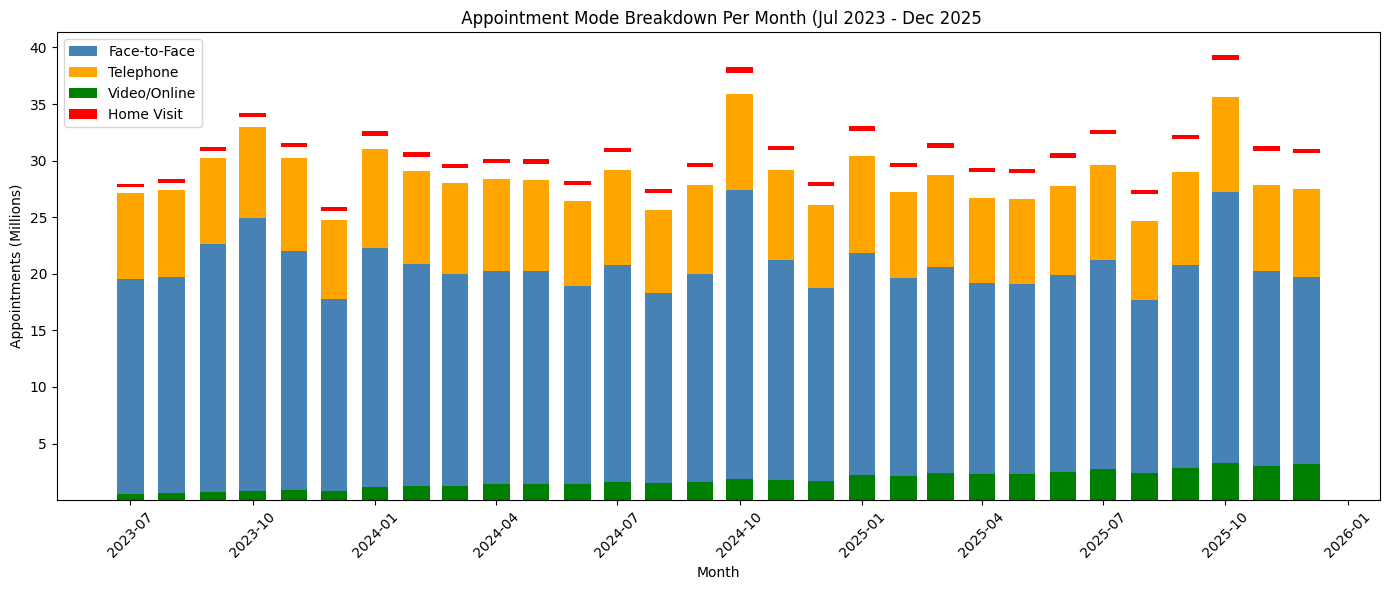

In [ ]:
# consultation mode analysis
#mode over time
plt.figure(figsize=(14, 6))

plt.bar(gp_data['Month'], gp_data['Total_F2F']/ 1000000,
        color='steelblue', width=20, label='Face-to-Face')

plt.bar(gp_data['Month'], gp_data['Total_Tel']/ 1000000,
        bottom=gp_data['Total_F2F']/ 1000000,
        color='orange', width=20, label='Telephone')

plt.bar(gp_data['Month'], gp_data['Total_Video_Online']/ 1000000,
        bottom=(gp_data['Total_F2F']/+ gp_data['Total_Tel'])/ 1000000,
        color='green', width=20, label='Video/Online')
plt.bar(gp_data['Month'], gp_data['Total_Home_Visit']/ 1000000,
        bottom=(gp_data['Total_F2F']+gp_data['Total_Tel'] + gp_data['Total_Video_Online'])/ 1000000,
        color = 'red', width=20, label='Home Visit')

plt.title(' Appointment Mode Breakdown Per Month (Jul 2023 - Dec 2025')
plt.xlabel('Month')
plt.ylabel('Appointments (Millions)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('mode_breakdown.png', dpi=150)
plt.show()

In [ ]:
# growth in each mode from start to end
for col, label in [('Total_F2F', 'F2F'), ('Total_Tel', 'Telephone'),
                   ('Total_Video_Online', 'Video/Online'), ('Total_Home_Visit', 'Home Visit')]:
    change = (gp_data[col].iloc[-1] - gp_data[col].iloc[0]) / gp_data[col].iloc[0] * 100
    print(f"{label} change (Jul 2023 to Dec 2025): {round(change, 1)}%")


F2F change (Jul 2023 to Dec 2025): 1.0%
Telephone change (Jul 2023 to Dec 2025): 2.8%
Video/Online change (Jul 2023 to Dec 2025): 472.5%
Home Visit change (Jul 2023 to Dec 2025): 38.9%


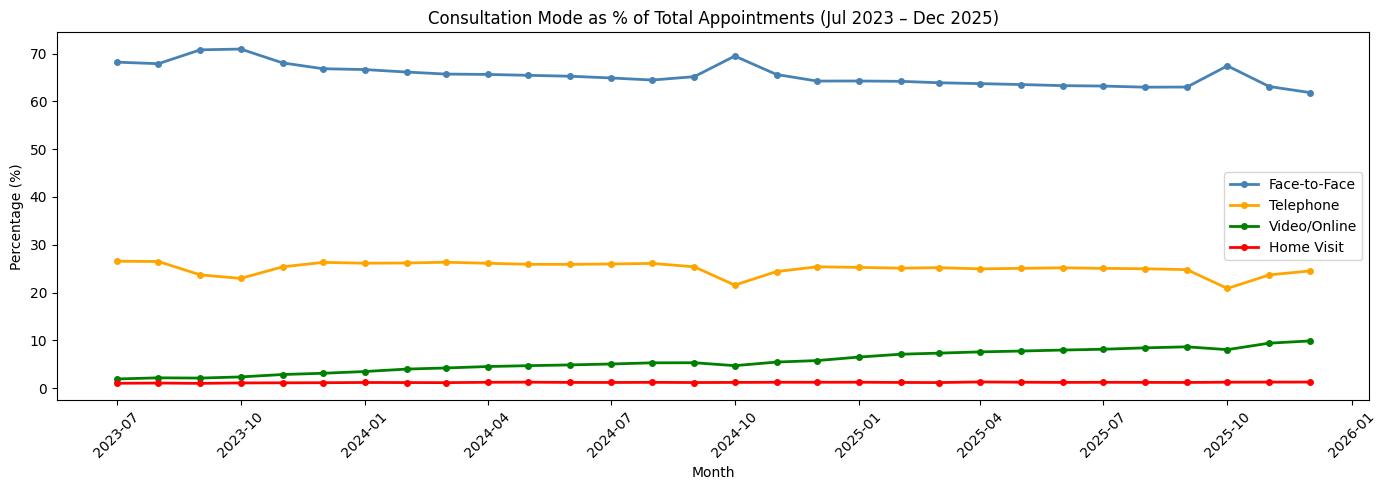

In [ ]:
#mode as percentage of total
gp_data['Pct_F2F']        = gp_data['Total_F2F']         / gp_data['Total_Appointments'] * 100
gp_data['Pct_Tel']        = gp_data['Total_Tel']          / gp_data['Total_Appointments'] * 100
gp_data['Pct_Video']      = gp_data['Total_Video_Online'] / gp_data['Total_Appointments'] * 100
gp_data['Pct_Home_Visit'] = gp_data['Total_Home_Visit']   / gp_data['Total_Appointments'] * 100

plt.figure(figsize=(14, 5))

plt.plot(gp_data['Month'], gp_data['Pct_F2F'],
         color='steelblue', linewidth=2, marker='o', markersize=4, label='Face-to-Face')

plt.plot(gp_data['Month'], gp_data['Pct_Tel'],
         color='orange', linewidth=2, marker='o', markersize=4, label='Telephone')

plt.plot(gp_data['Month'], gp_data['Pct_Video'],
         color='green', linewidth=2, marker='o', markersize=4, label='Video/Online')

plt.plot(gp_data['Month'], gp_data['Pct_Home_Visit'],
         color='red', linewidth=2, marker='o', markersize=4, label='Home Visit')

plt.title('Consultation Mode as % of Total Appointments (Jul 2023 – Dec 2025)')
plt.xlabel('Month')
plt.ylabel('Percentage (%)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('mode_percentage.png', dpi=150)
plt.show()

In [ ]:
# has F2F share grown or shrunk?
f2f_first = gp_data['Pct_F2F'].iloc[0]
f2f_last  = gp_data['Pct_F2F'].iloc[-1]
tel_first = gp_data['Pct_Tel'].iloc[0]
tel_last  = gp_data['Pct_Tel'].iloc[-1]

print(f"F2F share:       {round(f2f_first, 1)}% (Jul 2023) → {round(f2f_last, 1)}% (Dec 2025)")
print(f"Telephone share: {round(tel_first, 1)}% (Jul 2023) → {round(tel_last, 1)}% (Dec 2025)")

F2F share:       68.2% (Jul 2023) → 61.8% (Dec 2025)
Telephone share: 26.6% (Jul 2023) → 24.5% (Dec 2025)


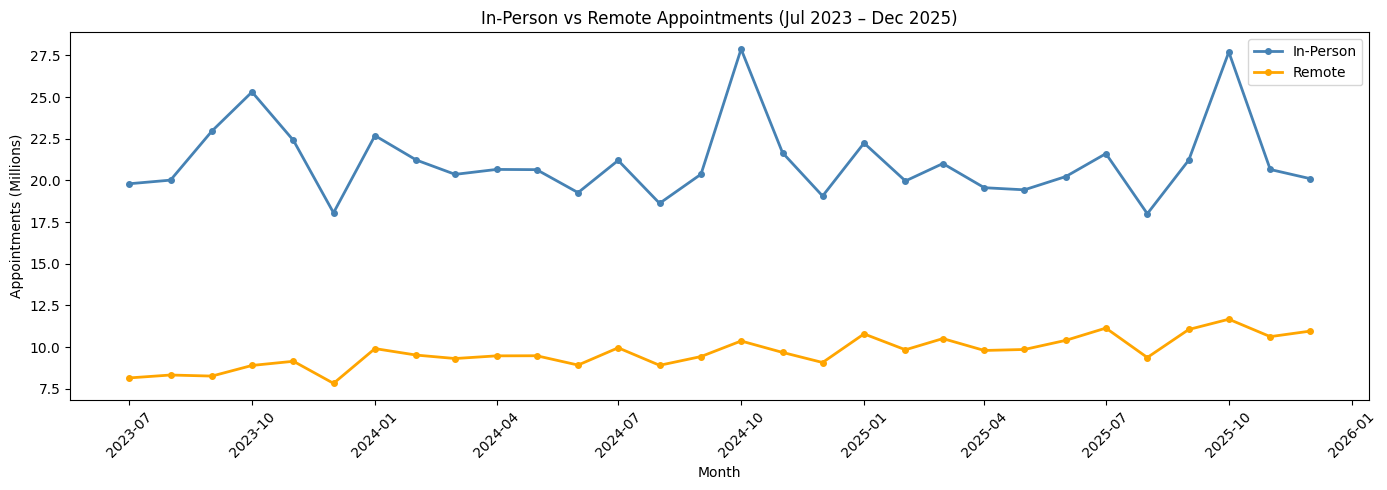

In [ ]:
#remote vs in-person
gp_data['Remote']    = gp_data['Total_Tel'] + gp_data['Total_Video_Online']
gp_data['InPerson']  = gp_data['Total_F2F'] + gp_data['Total_Home_Visit']

plt.figure(figsize=(14, 5))

plt.plot(gp_data['Month'], gp_data['InPerson'] / 1000000,
         color='steelblue', linewidth=2, marker='o', markersize=4, label='In-Person')

plt.plot(gp_data['Month'], gp_data['Remote'] / 1000000,
         color='orange', linewidth=2, marker='o', markersize=4, label='Remote')

plt.title('In-Person vs Remote Appointments (Jul 2023 – Dec 2025)')
plt.xlabel('Month')
plt.ylabel('Appointments (Millions)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('remote_vs_inperson.png', dpi=150)
plt.show()

In [ ]:
remote_first = gp_data['Remote'].iloc[0] / gp_data['Total_Appointments'].iloc[0] * 100
remote_last  = gp_data['Remote'].iloc[-1] / gp_data['Total_Appointments'].iloc[-1] * 100
print(f"Remote share Jul 2023: {round(remote_first, 1)}%")
print(f"Remote share Dec 2025: {round(remote_last, 1)}%")
print(f"Change: {round(remote_last - remote_first, 1)} percentage points")

Remote share Jul 2023: 28.5%
Remote share Dec 2025: 34.4%
Change: 5.9 percentage points


In [ ]:
print("BLOCK 2 - Consultation Mode Summary")
print("-" * 40)
print("Average % Face-to-Face:", round(gp_data['Pct_F2F'].mean(), 1))
print("Average % Telephone:", round(gp_data['Pct_Tel'].mean(), 1))
print("Average % Video/Online:", round(gp_data['Pct_Video'].mean(), 1))
print("Average % Home Visit:", round(gp_data['Pct_Home_Visit'].mean(), 1))
print("")
print("Average monthly in-person appointments:", round(gp_data['InPerson'].mean()))
print("Average monthly remote appointments:", round(gp_data['Remote'].mean()))
print("")
print("Remote % of total (average):", round(gp_data['Remote'] / gp_data['Total_Appointments'].mean() * 100, 1).mean())
print("In-Person % of total (average):", round(gp_data['InPerson'] / gp_data['Total_Appointments'].mean() * 100, 1).mean())

BLOCK 2 - Consultation Mode Summary
----------------------------------------
Average % Face-to-Face: 65.5
Average % Telephone: 25.0
Average % Video/Online: 5.6
Average % Home Visit: 1.2

Average monthly in-person appointments: 21128540
Average monthly remote appointments: 9684731

Remote % of total (average): 30.610000000000003
In-Person % of total (average): 66.78333333333333


In [ ]:
wait_cols = ['Total_SameDay', 'Total_1Day', 'Total_2to7Days',
             'Total_8to14Days', 'Total_15to21Days', 'Total_22to28Days',
             'Total_Over28Days']
print(gp_data[wait_cols].head())
print(gp_data[wait_cols].isnull().sum())

   Total_SameDay  Total_1Day  Total_2to7Days  Total_8to14Days  \
0       12394406     2181822         5613006          3765150   
1       12633099     2379070         5303708          3759124   
2       12636469     2443387         5937819          4163471   
3       13761922     2557490         6549504          4748103   
4       13743524     2613934         6155234          4338470   

   Total_15to21Days  Total_22to28Days  Total_Over28Days  
0           2060476           1330814           1221220  
1           2117305           1402949           1401463  
2           2560351           1807015           2404497  
3           2846418           1980150           2645151  
4           2417632           1544093           1539137  
Total_SameDay       0
Total_1Day          0
Total_2to7Days      0
Total_8to14Days     0
Total_15to21Days    0
Total_22to28Days    0
Total_Over28Days    0
dtype: int64


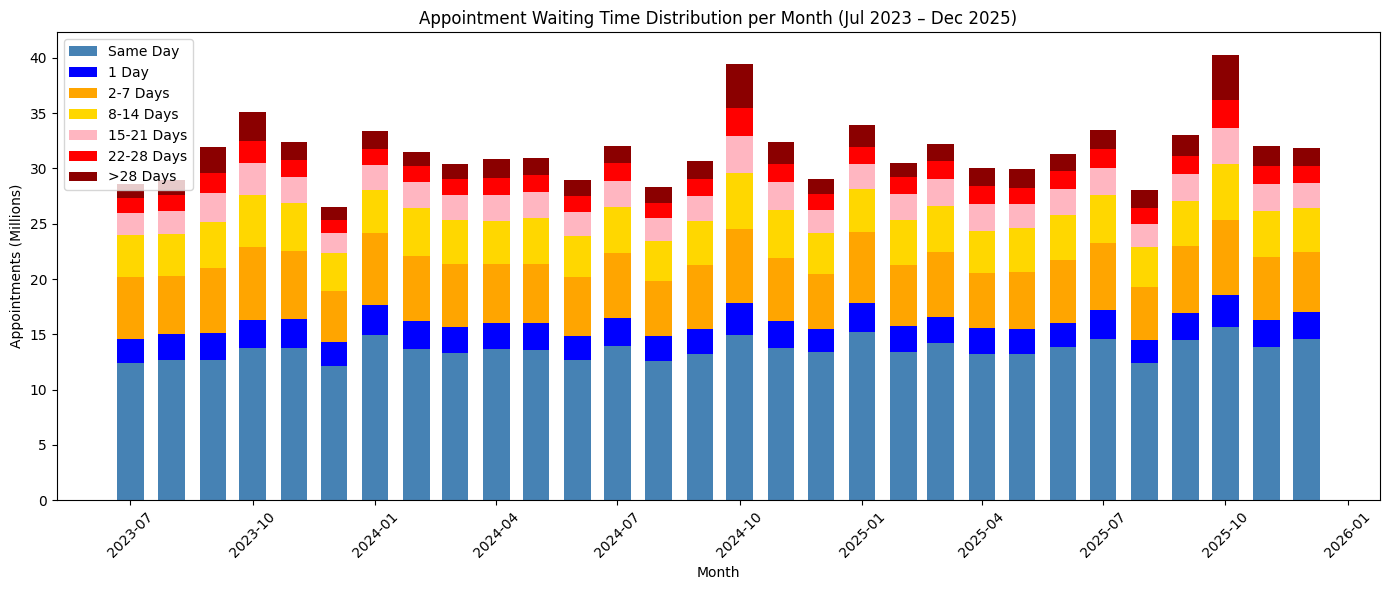

In [ ]:
#Block 2: Wait Time Analysis

#wait time distribution
wait_cols   = ['Total_SameDay', 'Total_1Day', 'Total_2to7Days',
               'Total_8to14Days', 'Total_15to21Days',
               'Total_22to28Days', 'Total_Over28Days']

wait_labels = ['Same Day', '1 Day', '2-7 Days',
               '8-14 Days', '15-21 Days',
               '22-28 Days', '>28 Days']

wait_colors = ['steelblue', 'blue', 'orange',
               'gold', 'lightpink', 'red', 'darkred']

plt.figure(figsize=(14, 6))

bottom = [0] * len(gp_data)

for col, label, color in zip(wait_cols, wait_labels, wait_colors):
    plt.bar(gp_data['Month'], gp_data[col] / 1000000,
            bottom=bottom, color=color, width=20, label=label)
    bottom = [b + v for b, v in zip(bottom, gp_data[col] / 1000000)]

plt.title('Appointment Waiting Time Distribution per Month (Jul 2023 – Dec 2025)')
plt.xlabel('Month')
plt.ylabel('Appointments (Millions)')
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('waiting_time_stacked.png', dpi=150)
plt.show()

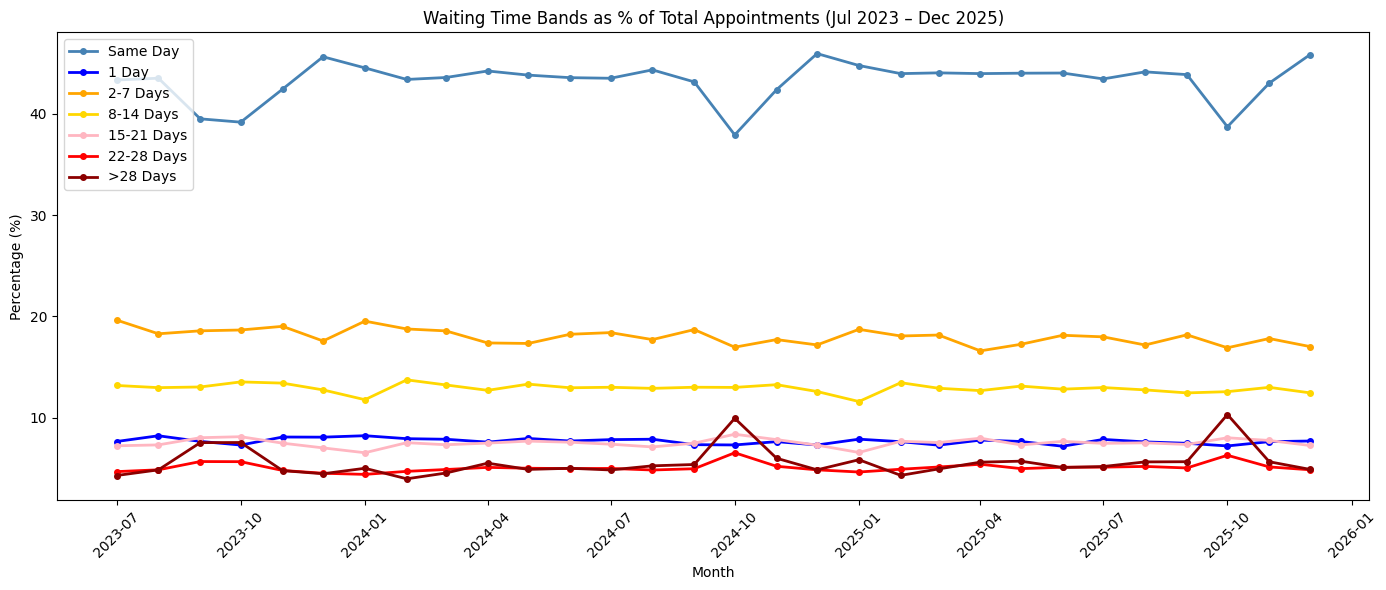

In [ ]:
for col, label in zip(wait_cols, wait_labels):
    gp_data['Pct_' + col] = gp_data[col] / gp_data['Total_Appointments'] * 100

plt.figure(figsize=(14, 6))

for col, label, color in zip(wait_cols, wait_labels, wait_colors):
    plt.plot(gp_data['Month'], gp_data['Pct_' + col],
             linewidth=2, marker='o', markersize=4,
             color=color, label=label)

plt.title('Waiting Time Bands as % of Total Appointments (Jul 2023 – Dec 2025)')
plt.xlabel('Month')
plt.ylabel('Percentage (%)')
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('waiting_time_pct.png', dpi=150)
plt.show()

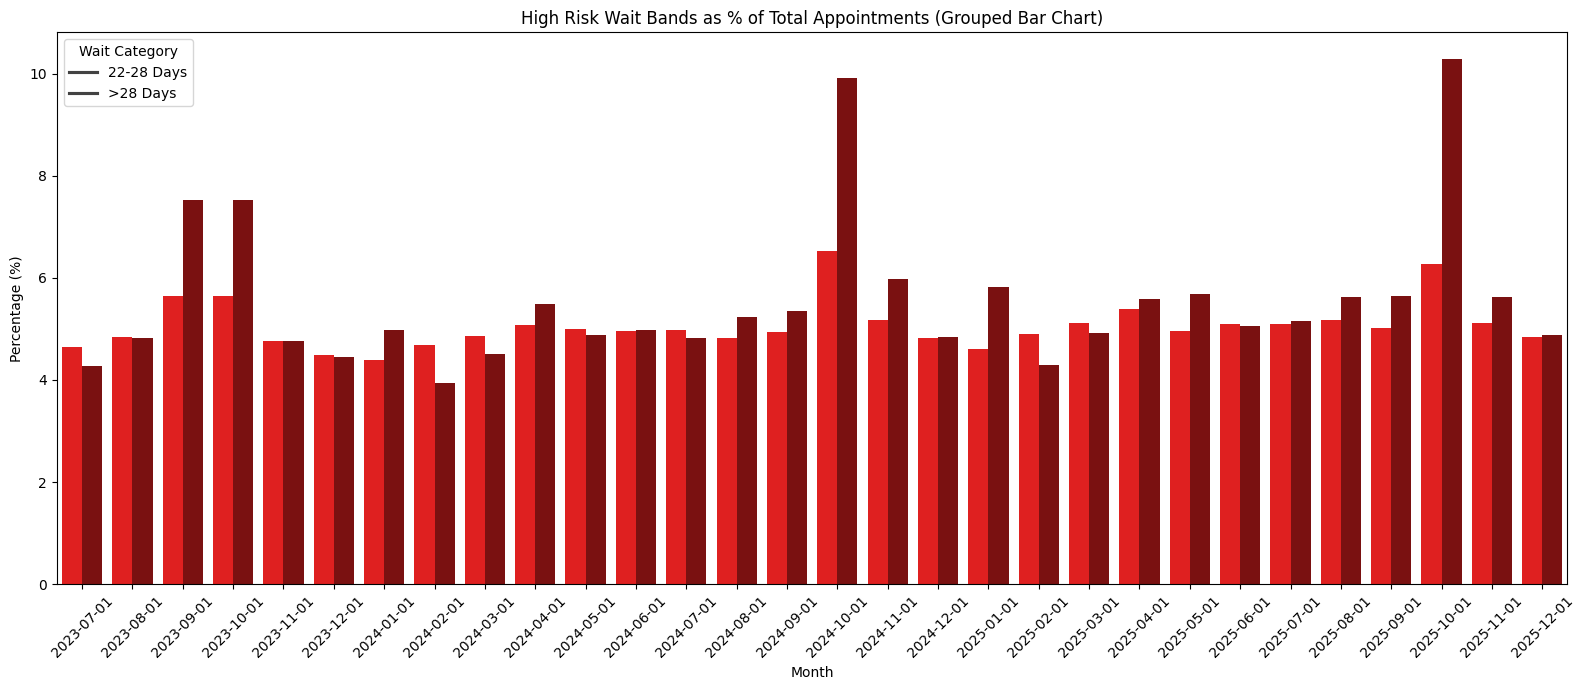

In [ ]:
# Grouped Bar Chart for High Risk Wait Bands
plot_df = gp_data[['Month', 'Pct_Total_22to28Days', 'Pct_Total_Over28Days']].melt('Month', var_name='Wait_Category', value_name='Percentage')

plt.figure(figsize=(16, 7))

sns.barplot(x='Month', y='Percentage', hue='Wait_Category', data=plot_df,
            palette={'Pct_Total_22to28Days': 'red', 'Pct_Total_Over28Days': 'darkred'})

plt.title('High Risk Wait Bands as % of Total Appointments (Grouped Bar Chart)')
plt.xlabel('Month')
plt.ylabel('Percentage (%)')
plt.legend(title='Wait Category', labels=['22-28 Days', '>28 Days'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('high_risk_wait_grouped_bar.png', dpi=150)
plt.show()

In [ ]:
# average % per band across all months
print("ANALYSIS - WAITING TIME DISTRIBUTION")
print("-" * 40)
print("Average % of appointments per wait band:")
for col, label in zip(wait_cols, wait_labels):
    avg = gp_data['Pct_' + col].mean()
    print(f"  {label:<12}: {round(avg, 1)}%")

print("")

# same day trend
sd_first = gp_data['Pct_Total_SameDay'].iloc[0]
sd_last  = gp_data['Pct_Total_SameDay'].iloc[-1]
print(f"Same Day share: {round(sd_first, 1)}% (Jul 2023) \u2192 {round(sd_last, 1)}% (Dec 2025)")

# Add the calculation for High_Risk_Wait and Pct_High_Risk
gp_data['High_Risk_Wait'] = gp_data['Total_22to28Days'] + gp_data['Total_Over28Days']
gp_data['Pct_High_Risk']  = gp_data['Pct_Total_22to28Days'] + gp_data['Pct_Total_Over28Days']

# high risk trend
hr_first = gp_data['Pct_High_Risk'].iloc[0]
hr_last  = gp_data['Pct_High_Risk'].iloc[-1]
hr_avg   = gp_data['Pct_High_Risk'].mean()
hr_peak  = gp_data['Pct_High_Risk'].max()
hr_peak_month = gp_data.loc[gp_data['Pct_High_Risk'].idxmax(), 'Month'].strftime('%b %Y')

print(f"\nHigh risk wait (22+ days):")
print(f"  Jul 2023:     {round(hr_first, 1)}%")
print(f"  Dec 2025:     {round(hr_last, 1)}%")
print(f"  Average:      {round(hr_avg, 1)}%")
print(f"  Peak:         {hr_peak_month} ({round(hr_peak, 1)}%)")

# absolute numbers in high risk bands
avg_high_risk_count = gp_data['High_Risk_Wait'].mean()
print(f"\nAverage monthly appointments in high risk bands: {round(avg_high_risk_count):,}")
print(f"Total high risk appointments (30 months): {gp_data['High_Risk_Wait'].sum():,}")

# over 28 days specifically
avg_over28 = gp_data['Total_Over28Days'].mean()
print(f"\nAverage monthly appointments waiting over 28 days: {round(avg_over28):,}")

ANALYSIS - WAITING TIME DISTRIBUTION
----------------------------------------
Average % of appointments per wait band:
  Same Day    : 43.3%
  1 Day       : 7.7%
  2-7 Days    : 18.0%
  8-14 Days   : 12.9%
  15-21 Days  : 7.5%
  22-28 Days  : 5.1%
  >28 Days    : 5.6%

Same Day share: 43.3% (Jul 2023) → 45.8% (Dec 2025)

High risk wait (22+ days):
  Jul 2023:     8.9%
  Dec 2025:     9.7%
  Average:      10.6%
  Peak:         Oct 2025 (16.6%)

Average monthly appointments in high risk bands: 3,402,551
Total high risk appointments (30 months): 102,076,519

Average monthly appointments waiting over 28 days: 1,792,730


In [ ]:
dna_cols= ['Total_DNA', 'Total_Attended', 'Total_Unknown_Status',
           'Pct_DNA', 'Pct_Attended', 'Pct_Unknown']

print(gp_data[dna_cols].head())
print(gp_data[dna_cols].isnull().sum())
print(df[['DNA Count', 'PCN DNA Count', 'Total Appts', 'PCN Total Appts']].head())

   Total_DNA  Total_Attended  Total_Unknown_Status   Pct_DNA  Pct_Attended  \
0    1297099        25766044               1535233  0.045356      0.900962   
1    1297474        26162600               1569279  0.044695      0.901246   
2    1666838        28254262               2066708  0.052109      0.883282   
3    1851222        30896760               2380215  0.052699      0.879543   
4    1531776        28940074               1912900  0.047299      0.893633   

   Pct_Unknown  
0     0.053683  
1     0.054058  
2     0.064609  
3     0.067758  
4     0.059068  
Total_DNA               0
Total_Attended          0
Total_Unknown_Status    0
Pct_DNA                 0
Pct_Attended            0
Pct_Unknown             0
dtype: int64
   DNA Count  PCN DNA Count  Total Appts  PCN Total Appts
0    1227296          69803     27758901           839475
1    1231789          65685     28196774           832579
2    1592841          73997     31101518           886290
3    1775540          75682 

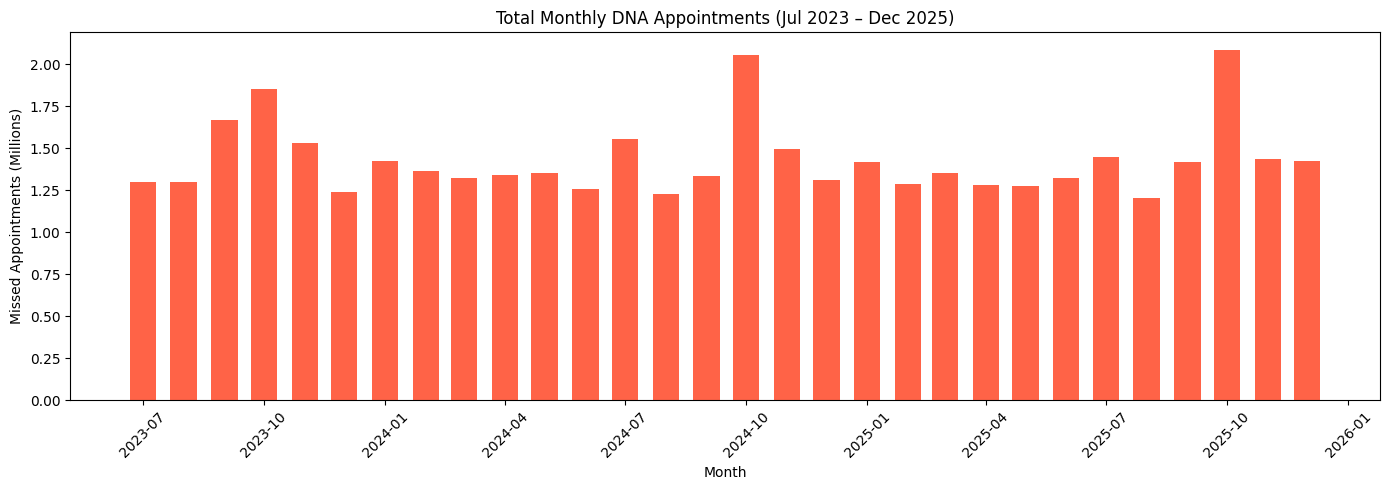

In [ ]:
#Block 4: DNA Analysis
#monthly dna count over time
plt.figure(figsize=(14, 5))

plt.bar(gp_data['Month'], gp_data['Total_DNA'] / 1000000,
        color='tomato', width=20, label='DNA Count')

plt.title('Total Monthly DNA Appointments (Jul 2023 – Dec 2025)')
plt.xlabel('Month')
plt.ylabel('Missed Appointments (Millions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('dna_count.png', dpi=150)
plt.show()

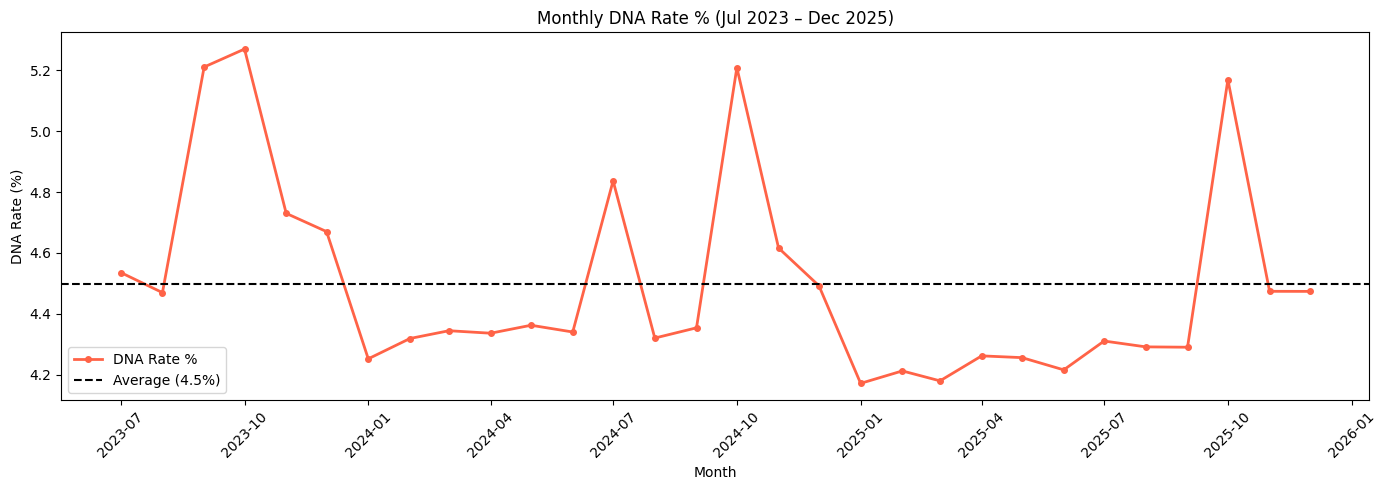

In [ ]:
#monthly dna rate
plt.figure(figsize=(14, 5))

plt.plot(gp_data['Month'], gp_data['Pct_DNA'] * 100,
         color='tomato', linewidth=2, marker='o', markersize=4,
         label='DNA Rate %')

# add average line
avg_dna = gp_data['Pct_DNA'].mean() * 100
plt.axhline(y=avg_dna, color='black', linestyle='--',
            linewidth=1.5, label=f'Average ({round(avg_dna, 1)}%)')

plt.title('Monthly DNA Rate % (Jul 2023 – Dec 2025)')
plt.xlabel('Month')
plt.ylabel('DNA Rate (%)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('dna_rate.png', dpi=150)
plt.show()

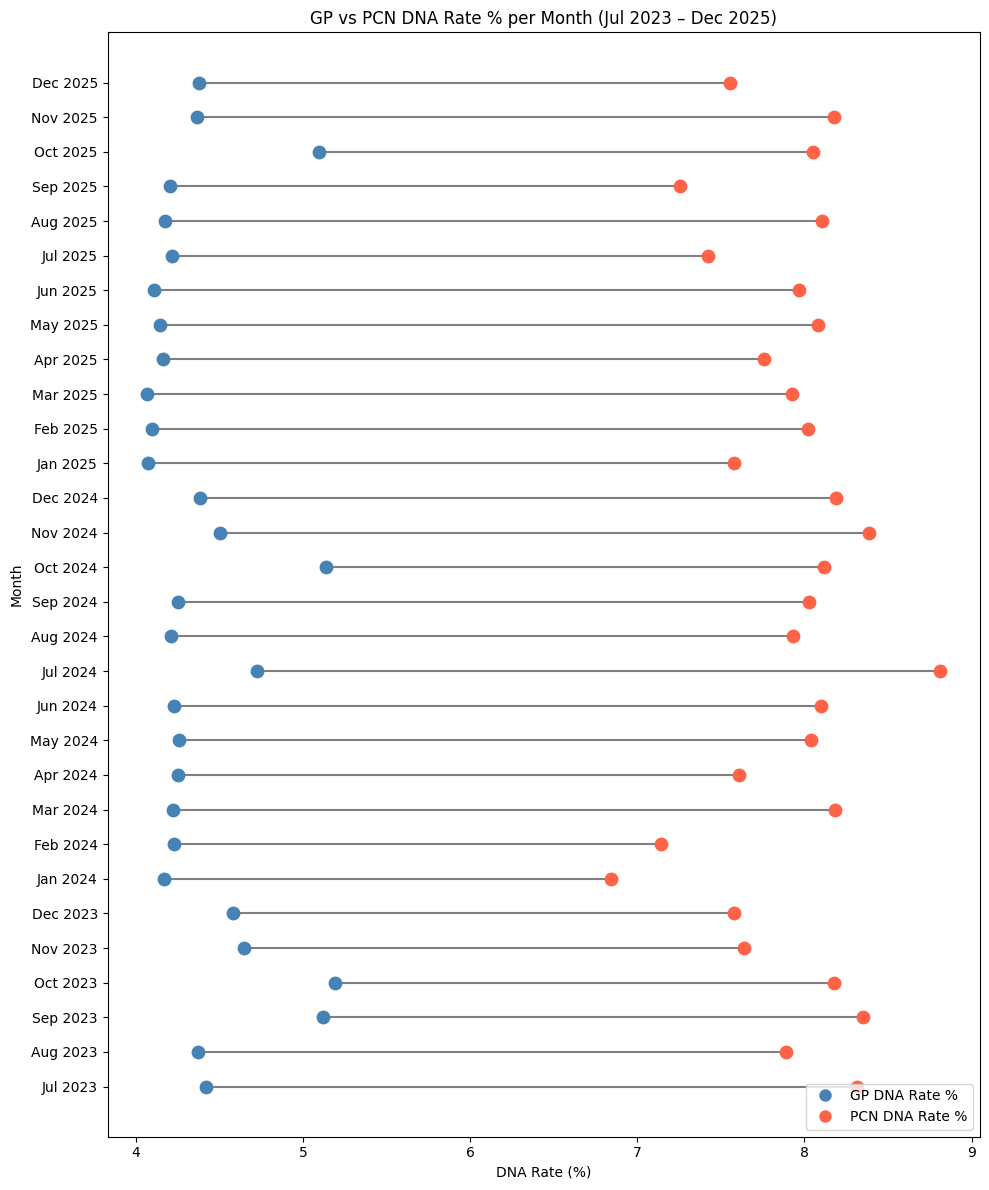

GAP ANALYSIS - PCN minus GP DNA Rate
----------------------------------------
Average gap: 3.51 percentage points
Largest gap: 4.09 pp in Jul 2024
Smallest gap: 2.67 pp in Jan 2024


In [ ]:
#gp vs pcn dna rate comparison
gp_dna_rate  = df['DNA Count']     / df['Total Appts']     * 100
pcn_dna_rate = df['PCN DNA Count'] / df['PCN Total Appts'] * 100

fig, ax = plt.subplots(figsize=(10, 12))

for i in range(len(gp_data)):
    month = gp_data['Month'].iloc[i].strftime('%b %Y')
    gp    = gp_dna_rate.iloc[i]
    pcn   = pcn_dna_rate.iloc[i]

    # draw the line connecting GP and PCN
    ax.plot([gp, pcn], [month, month],
            color='grey', linewidth=1.5, zorder=1)

    # draw GP dot
    ax.scatter(gp, month,
               color='steelblue', s=80, zorder=2)

    # draw PCN dot
    ax.scatter(pcn, month,
               color='tomato', s=80, zorder=2)

# add a legend manually
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=10, label='GP DNA Rate %'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato',
           markersize=10, label='PCN DNA Rate %')
]
ax.legend(handles=legend_elements, loc='lower right')

ax.set_title('GP vs PCN DNA Rate % per Month (Jul 2023 – Dec 2025)')
ax.set_xlabel('DNA Rate (%)')
ax.set_ylabel('Month')
plt.tight_layout()
plt.savefig('dna_dumbbell.png', dpi=150)
plt.show()

# print the gap analysis
gap = pcn_dna_rate - gp_dna_rate
print("GAP ANALYSIS - PCN minus GP DNA Rate")
print("-" * 40)
print(f"Average gap: {round(gap.mean(), 2)} percentage points")
print(f"Largest gap: {round(gap.max(), 2)} pp in {gp_data.loc[gap.idxmax(), 'Month'].strftime('%b %Y')}")
print(f"Smallest gap: {round(gap.min(), 2)} pp in {gp_data.loc[gap.idxmin(), 'Month'].strftime('%b %Y')}")

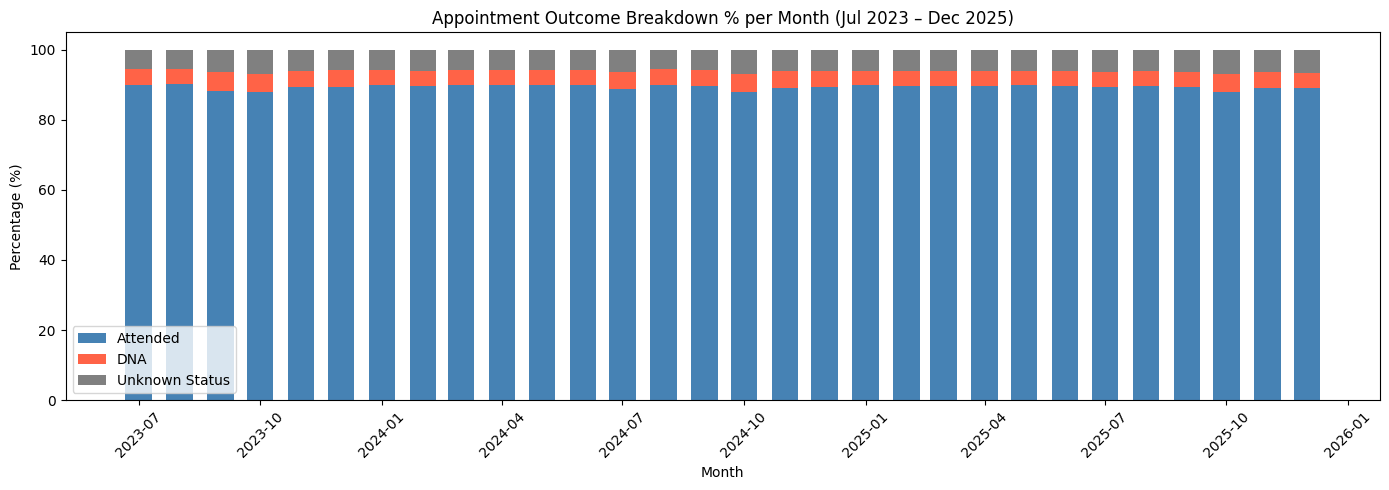

In [ ]:
#attended vs unattended vs unknown
plt.figure(figsize=(14, 5))

plt.bar(gp_data['Month'], gp_data['Pct_Attended'] * 100,
        color='steelblue', width=20, label='Attended')

plt.bar(gp_data['Month'], gp_data['Pct_DNA'] * 100,
        bottom=gp_data['Pct_Attended'] * 100,
        color='tomato', width=20, label='DNA')

plt.bar(gp_data['Month'], gp_data['Pct_Unknown'] * 100,
        bottom=(gp_data['Pct_Attended'] + gp_data['Pct_DNA']) * 100,
        color='grey', width=20, label='Unknown Status')

plt.title('Appointment Outcome Breakdown % per Month (Jul 2023 – Dec 2025)')
plt.xlabel('Month')
plt.ylabel('Percentage (%)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outcome_breakdown.png', dpi=150)
plt.show()

In [ ]:
#analysis
print("ANALYSIS - DNA OVERVIEW")
print("-" * 40)

# overall dna scale
total_dna    = gp_data['Total_DNA'].sum()
avg_dna      = gp_data['Total_DNA'].mean()
avg_dna_rate = gp_data['Pct_DNA'].mean() * 100

print(f"Total DNA appointments (30 months): {total_dna:,}")
print(f"Average monthly DNA count:          {round(avg_dna):,}")
print(f"Average monthly DNA rate:           {round(avg_dna_rate, 2)}%")

# peak and low dna
peak_dna_month = gp_data.loc[gp_data['Total_DNA'].idxmax(), 'Month'].strftime('%b %Y')
peak_dna_val   = gp_data['Total_DNA'].max()
low_dna_month  = gp_data.loc[gp_data['Total_DNA'].idxmin(), 'Month'].strftime('%b %Y')
low_dna_val    = gp_data['Total_DNA'].min()

print(f"\nPeak DNA month:   {peak_dna_month} ({peak_dna_val:,})")
print(f"Lowest DNA month: {low_dna_month} ({low_dna_val:,})")

# dna trend
dna_first = gp_data['Pct_DNA'].iloc[0] * 100
dna_last  = gp_data['Pct_DNA'].iloc[-1] * 100
print(f"\nDNA rate Jul 2023: {round(dna_first, 2)}%")
print(f"DNA rate Dec 2025: {round(dna_last, 2)}%")
print(f"Change:            {round(dna_last - dna_first, 2)} percentage points")

# gp vs pcn dna rate
avg_gp_dna  = (df['DNA Count'] / df['Total Appts'] * 100).mean()
avg_pcn_dna = (df['PCN DNA Count'] / df['PCN Total Appts'] * 100).mean()

print(f"\nAverage GP DNA rate:  {round(avg_gp_dna, 2)}%")
print(f"Average PCN DNA rate: {round(avg_pcn_dna, 2)}%")
print(f"PCN DNA rate is {round(avg_pcn_dna / avg_gp_dna, 1)}x higher than GP DNA rate")

# seasonal pattern
gp_data['Month_Num'] = gp_data['Month'].dt.month
monthly_dna = gp_data.groupby('Month_Num')['Pct_DNA'].mean() * 100
print(f"\nAverage DNA rate by calendar month:")
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
for m, rate in monthly_dna.items():
    print(f"  {month_names[m-1]}: {round(rate, 2)}%")

ANALYSIS - DNA OVERVIEW
----------------------------------------
Total DNA appointments (30 months): 42,857,002
Average monthly DNA count:          1,428,567
Average monthly DNA rate:           4.5%

Peak DNA month:   Oct 2025 (2,085,246)
Lowest DNA month: Aug 2025 (1,203,501)

DNA rate Jul 2023: 4.54%
DNA rate Dec 2025: 4.47%
Change:            -0.06 percentage points

Average GP DNA rate:  4.4%
Average PCN DNA rate: 7.91%
PCN DNA rate is 1.8x higher than GP DNA rate

Average DNA rate by calendar month:
  Jan: 4.21%
  Feb: 4.27%
  Mar: 4.26%
  Apr: 4.3%
  May: 4.31%
  Jun: 4.28%
  Jul: 4.56%
  Aug: 4.36%
  Sep: 4.62%
  Oct: 5.22%
  Nov: 4.61%
  Dec: 4.55%


# **Section 2 — Cost Impact Analysis**

The NHS publishes unit costs for primary care appointments through the National Schedule
of NHS Costs. The most widely cited and defensible figure for a GP appointment is **£30**
(NHS England, 2022-23) [link text](https://www.florenceroadsurgery.nhs.uk/2025/04/10/understanding-the-impact-of-missed-appointments-on-the-nhs/
). This
figure is applied as a constant throughout this section — all
cost estimates are approximations based on this unit cost and should be interpreted as
indicative rather than exact.

Using the 30-month dataset (July 2023 – December 2025), we estimate the total financial
burden of missed GP appointments and examine how that cost has trended over time.


In [ ]:
#Block 1 : Total Financial Cost of DNAs

#unit cost per GP appointment
cost_per_apt = 30 #£

#monthly dna cost and cumulative cost
gp_data['DNA_cost']= gp_data['Total_DNA'] * cost_per_apt
gp_data['Cumulative_cost']= gp_data['DNA_cost'].cumsum()

total_cost= gp_data['DNA_cost'].sum()
avg_monthly= gp_data['DNA_cost'].mean()
peak_month= gp_data.loc[gp_data['DNA_cost'].idxmax(), 'Month']
peak_cost= gp_data['DNA_cost'].max()

print(f"Total DNA cost (30 months):       £{total_cost:,.0f}")
print(f"Average monthly DNA cost:         £{avg_monthly:,.0f}")
print(f"Peak cost month:                  {peak_month.strftime('%b %Y')}")
print(f"Peak monthly DNA cost:            £{peak_cost:,.0f}")
print(f"Cumulative cost at end of period: £{gp_data['Cumulative_cost'].iloc[-1]:,.0f}")

Total DNA cost (30 months):       £1,285,710,060
Average monthly DNA cost:         £42,857,002
Peak cost month:                  Oct 2025
Peak monthly DNA cost:            £62,557,380
Cumulative cost at end of period: £1,285,710,060


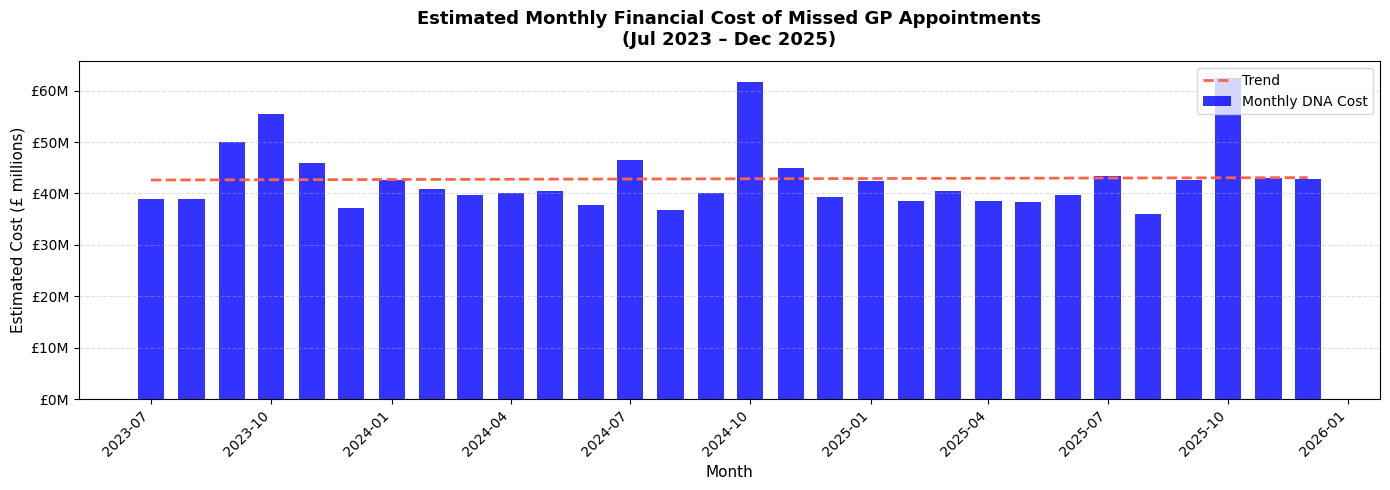

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, ax = plt.subplots(figsize=(14, 5))

# bar chart
bars = ax.bar(gp_data['Month'], gp_data['DNA_cost'] / 1e6,
              color='blue', alpha=0.8, width=20, label='Monthly DNA Cost')

# trend line
x_num = np.arange(len(gp_data))
z = np.polyfit(x_num, gp_data['DNA_cost'] / 1e6, 1)
p = np.poly1d(z)
ax.plot(gp_data['Month'], p(x_num), color='tomato', linewidth=2,
        linestyle='--', label='Trend')

# formatting
ax.set_title('Estimated Monthly Financial Cost of Missed GP Appointments\n(Jul 2023 – Dec 2025)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Estimated Cost (£ millions)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:.0f}M'))
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('s2_b1_monthly_dna_cost.png', dpi=150)
plt.show()

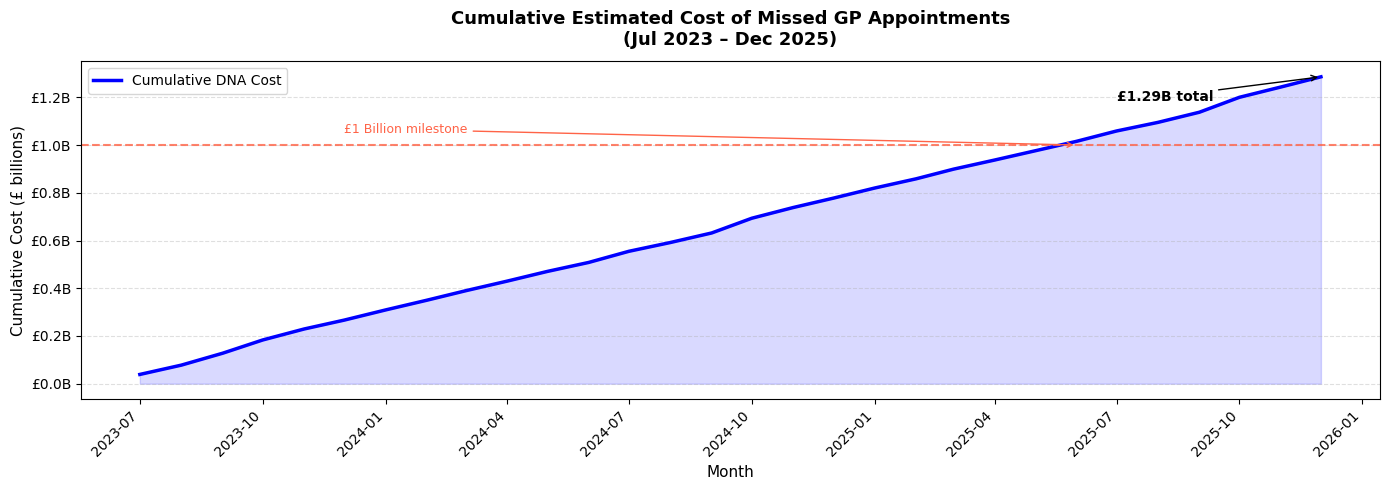

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

# cumulative cost line
ax.plot(gp_data['Month'], gp_data['Cumulative_cost'] / 1e9,
        color='blue', linewidth=2.5, label='Cumulative DNA Cost')

# shade under the line
ax.fill_between(gp_data['Month'], gp_data['Cumulative_cost'] / 1e9,
                alpha=0.15, color='blue')

billion_idx = (gp_data['Cumulative_cost'] >= 1e9).idxmax()
billion_month = gp_data.loc[billion_idx, 'Month']
ax.axhline(y=1, color='tomato', linestyle='--', linewidth=1.5, alpha=0.8)
ax.annotate('£1 Billion milestone',
            xy=(billion_month, 1),
            xytext=(gp_data['Month'].iloc[5], 1.05),
            fontsize=9, color='tomato',
            arrowprops=dict(arrowstyle='->', color='tomato'))
final_val = gp_data['Cumulative_cost'].iloc[-1] / 1e9
ax.annotate(f'£{final_val:.2f}B total',
            xy=(gp_data['Month'].iloc[-1], final_val),
            xytext=(gp_data['Month'].iloc[-6], final_val - 0.1),
            fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black'))

# formatting
ax.set_title('Cumulative Estimated Cost of Missed GP Appointments\n(Jul 2023 – Dec 2025)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Cumulative Cost (£ billions)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:.1f}B'))
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('s2_b1_cumulative_dna_cost.png', dpi=150)
plt.show()

In [ ]:
# analysis stats
print("Total Financial Cost of DNAs")
print('-'*40)
print(f"Total DNA cost over 30 months:    £{total_cost:,.0f}  (~£{total_cost/1e9:.2f}B)")
print(f"Average monthly DNA cost:         £{avg_monthly:,.0f}  (~£{avg_monthly/1e6:.1f}M)")
print(f"Peak monthly cost:                £{peak_cost:,.0f} ({peak_month.strftime('%b %Y')})")

# year-by-year breakdown
for year in [2023, 2024, 2025]:
    subset = gp_data[gp_data['Year'] == year]
    yr_cost = subset['DNA_cost'].sum()
    print(f"{year} total DNA cost:               £{yr_cost:,.0f}  (~£{yr_cost/1e6:.0f}M)")

# cost trend
slope_monthly = z[0]
print(f"\nMonthly cost trend:               +£{slope_monthly:.2f}M per month")
print(f"Annual cost increase rate:        +£{slope_monthly*12:.1f}M per year")

Total Financial Cost of DNAs
----------------------------------------
Total DNA cost over 30 months:    £1,285,710,060  (~£1.29B)
Average monthly DNA cost:         £42,857,002  (~£42.9M)
Peak monthly cost:                £62,557,380 (Oct 2025)
2023 total DNA cost:               £266,550,150  (~£267M)
2024 total DNA cost:               £510,775,890  (~£511M)
2025 total DNA cost:               £508,384,020  (~£508M)

Monthly cost trend:               +£0.02M per month
Annual cost increase rate:        +£0.2M per year


In [ ]:
#Block 2: GP vs PCN Cost per 1000 appointments

#cost per 1000 appointmnets booked under GP
gp_data['gp_cost_per_1000']= (df['DNA Count']/df['Total Appts']) * 1000 * 30

#cost per 1000 appointments booked under PCN
gp_data['pcn_cost_per_1000']= (df['PCN DNA Count']/df['PCN Total Appts']) * 1000 * 30

print(gp_data[['Month', 'gp_cost_per_1000', 'pcn_cost_per_1000']].head(10))

       Month  gp_cost_per_1000  pcn_cost_per_1000
0 2023-07-01       1326.381041        2494.523363
1 2023-08-01       1310.563755        2366.802430
2 2023-09-01       1536.427579        2504.721931
3 2023-10-01       1557.361630        2453.620302
4 2023-11-01       1393.187357        2292.054083
5 2023-12-01       1374.166302        2273.122787
6 2024-01-01       1250.888202        2051.906282
7 2024-02-01       1267.616626        2142.923007
8 2024-03-01       1266.729344        2454.982960
9 2024-04-01       1274.827225        2282.642243


In [ ]:
#summary stats

avg_gp = gp_data['gp_cost_per_1000'].mean()
avg_pcn = gp_data['pcn_cost_per_1000'].mean()
gap = avg_pcn - avg_gp
ratio = avg_pcn / avg_gp

print("Summary Statistics")
print("-" * 40)
print (f"Average GP cost per 1000 appointments: £{avg_gp:,.0f}")
print(f"Average PCN cost per 1000 appointments: £{avg_pcn:,.0f}")
print(f"Average gap (PCN minus GP): £{gap:,.0f}")
print(f"PCN is {ratio:.1f}x more expensive per 1,000 appointments than GP")

Summary Statistics
----------------------------------------
Average GP cost per 1000 appointments: £1,319
Average PCN cost per 1000 appointments: £2,372
Average gap (PCN minus GP): £1,053
PCN is 1.8x more expensive per 1,000 appointments than GP


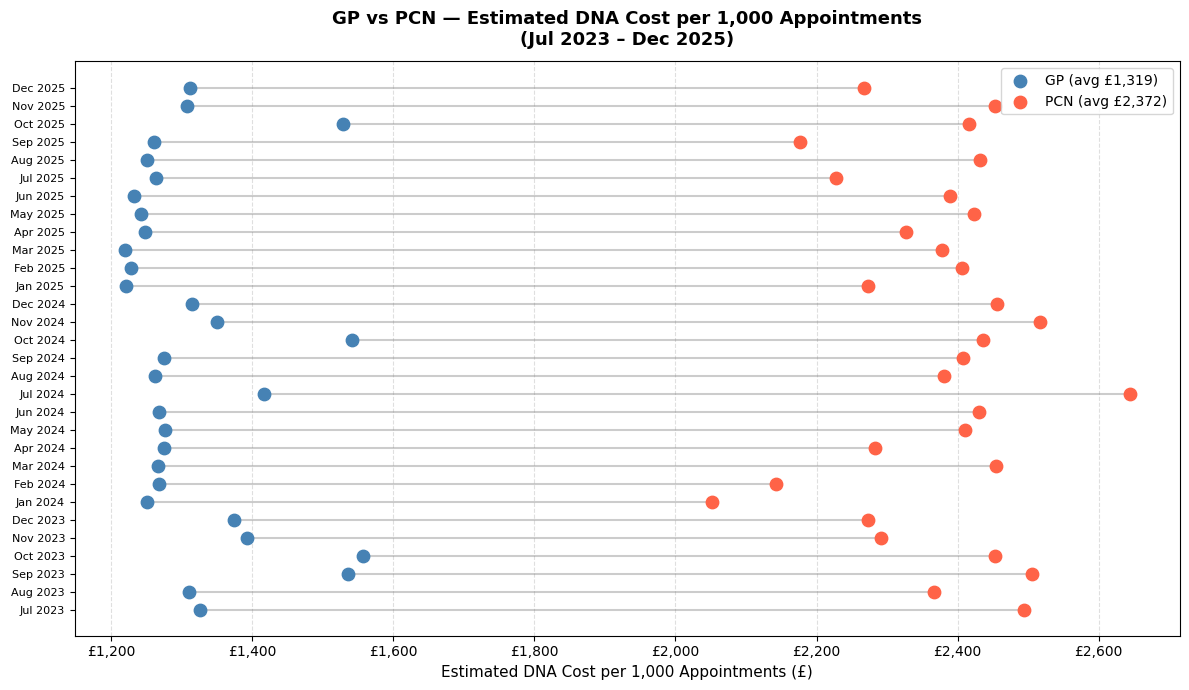

In [ ]:
# Dumbbell Chart — GP vs PCN Cost Per 1,000 Appointments

fig, ax = plt.subplots(figsize=(12, 7))

y_positions = range(len(gp_data))

#connecting lines (the gap)
ax.hlines(y=y_positions,
          xmin=gp_data['gp_cost_per_1000'],
          xmax=gp_data['pcn_cost_per_1000'],
          color='grey', alpha=0.4, linewidth=1.5)

#GP dots
ax.scatter(gp_data['gp_cost_per_1000'], y_positions,
           color='steelblue', s=80, zorder=3, label=f'GP (avg £{avg_gp:,.0f})')

# PCN dots
ax.scatter(gp_data['pcn_cost_per_1000'], y_positions,
           color='tomato', s=80, zorder=3, label=f'PCN (avg £{avg_pcn:,.0f})')

#replacing y-axis numbers with month names
month_labels = gp_data['Month'].dt.strftime('%b %Y')
ax.set_yticks(y_positions)
ax.set_yticklabels(month_labels, fontsize=8)

#formatting
ax.set_xlabel('Estimated DNA Cost per 1,000 Appointments (£)', fontsize=11)
ax.set_title('GP vs PCN — Estimated DNA Cost per 1,000 Appointments\n(Jul 2023 – Dec 2025)',
             fontsize=13, fontweight='bold', pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend(fontsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('s2_b2_gp_pcn_cost_dumbbell.png', dpi=150)
plt.show()

In [ ]:
#Block 3 : High Risk Wait Cost

gp_data['high_risk_appts']= gp_data['Total_Appointments'] * (gp_data['Pct_High_Risk']/100)

In [ ]:
print(gp_data[['Month', 'Total_Appointments', 'Pct_High_Risk', 'high_risk_appts']].head(5))

       Month  Total_Appointments  Pct_High_Risk  high_risk_appts
0 2023-07-01            28598376       8.923703        2552034.0
1 2023-08-01            29029353       9.660608        2804412.0
2 2023-09-01            31987808      13.165991        4211512.0
3 2023-10-01            35128197      13.166918        4625301.0
4 2023-11-01            32384750       9.520623        3083230.0


In [ ]:
# estimated DNA count from high-risk wait appointments
gp_data['high_risk_dna'] = gp_data['high_risk_appts'] * (gp_data['Pct_DNA'])
print(gp_data[['Month', 'high_risk_appts', 'Pct_DNA', 'high_risk_dna']].head(5))

       Month  high_risk_appts   Pct_DNA  high_risk_dna
0 2023-07-01        2552034.0  0.045356  115749.256159
1 2023-08-01        2804412.0  0.044695  125343.877119
2 2023-09-01        4211512.0  0.052109  219455.745109
3 2023-10-01        4625301.0  0.052699  243748.888331
4 2023-11-01        3083230.0  0.047299  145834.620199


In [ ]:
#cost of high-risk wait dna's

gp_data['high_risk_dna_cost']= gp_data['high_risk_dna'] *30
gp_data['routine_dna_cost']= gp_data['DNA_cost']- gp_data['high_risk_dna_cost']
print(gp_data[['Month', 'DNA_cost', 'high_risk_dna_cost', 'routine_dna_cost']].head(5))

       Month  DNA_cost  high_risk_dna_cost  routine_dna_cost
0 2023-07-01  38912970        3.472478e+06      3.544049e+07
1 2023-08-01  38924220        3.760316e+06      3.516390e+07
2 2023-09-01  50005140        6.583672e+06      4.342147e+07
3 2023-10-01  55536660        7.312467e+06      4.822419e+07
4 2023-11-01  45953280        4.375039e+06      4.157824e+07


In [ ]:
# Summary statistics

total_high_risk_cost = gp_data['high_risk_dna_cost'].sum()
total_routine_cost   = gp_data['routine_dna_cost'].sum()
total_dna_cost       = gp_data['DNA_cost'].sum()

high_risk_pct = (total_high_risk_cost / total_dna_cost) * 100
routine_pct   = (total_routine_cost   / total_dna_cost) * 100

print(f"Total DNA cost (30 months):         £{total_dna_cost:,.0f}")
print(f"High-risk wait DNA cost:            £{total_high_risk_cost:,.0f}  ({high_risk_pct:.1f}%)")
print(f"Routine wait DNA cost:              £{total_routine_cost:,.0f}  ({routine_pct:.1f}%)")

Total DNA cost (30 months):         £1,285,710,060
High-risk wait DNA cost:            £139,727,246  (10.9%)
Routine wait DNA cost:              £1,145,982,814  (89.1%)


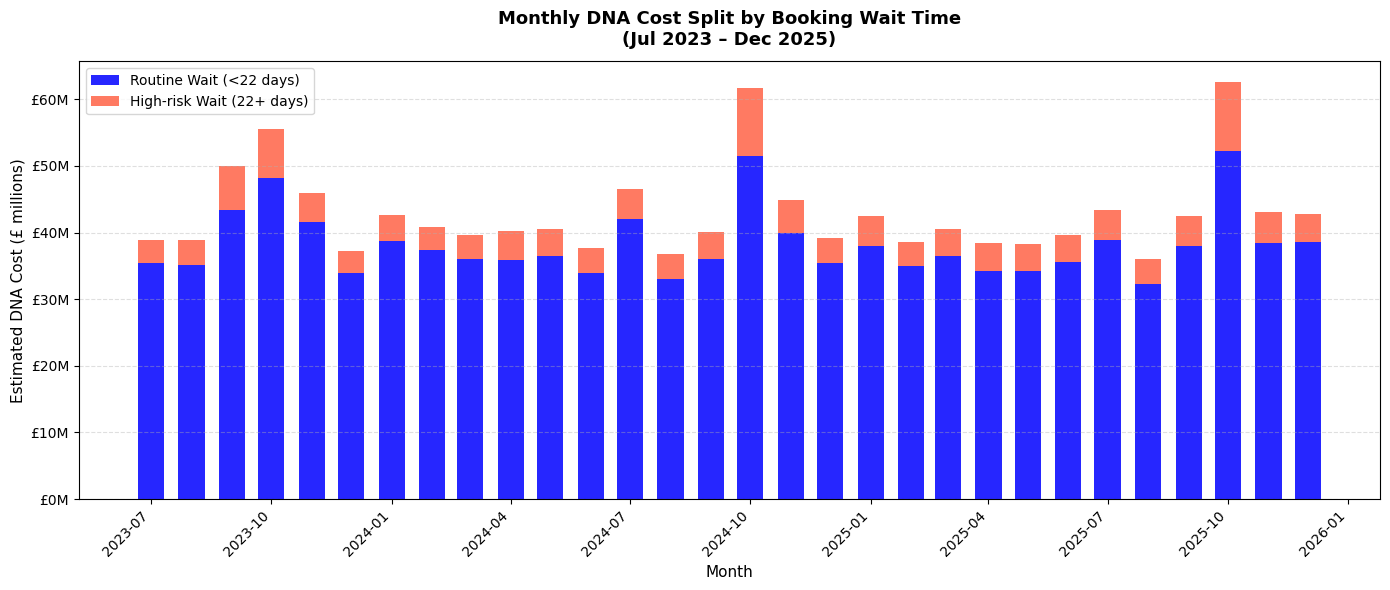

In [ ]:
fig, ax= plt.subplots(figsize=(14,6))

bars1= ax.bar(gp_data['Month'], gp_data['routine_dna_cost']/1e6,
              width= 20, color= 'blue', alpha=0.85, label='Routine Wait (<22 days)')

bars2= ax.bar(gp_data['Month'], gp_data['high_risk_dna_cost']/1e6,
              width= 20, color= 'tomato', alpha= 0.85,
              bottom= gp_data['routine_dna_cost']/1e6,
              label='High-risk Wait (22+ days)')
ax.set_title('Monthly DNA Cost Split by Booking Wait Time\n(Jul 2023 – Dec 2025)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Estimated DNA Cost (£ millions)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:.0f}M'))
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('s2_b3_stacked_cost.png', dpi=150)
plt.show()